# EDA: Avbokningar på hotell (Hotel Booking Demand)

**Problem:** Hotell överbokar för att kompensera för avbokningar. En modell som förutsäger vilka bokningar som avbokas minskar både tomma rum och överbokade gäster.  
**Användare:** Hotellets intäkts- eller bokningsansvarige.  

**Källa:** Antonio, N., de Almeida, A. & Nunes, L. (2019). Hotel booking demand datasets. *Data in Brief*, 22, 41–49. https://doi.org/10.1016/j.dib.2018.11.126  
**Licens:** CC BY 4.0 (källan ska anges)  
**Data:** Riktiga bokningar från två hotell i Portugal (ett semesterhotell i Algarve och ett stadshotell i Lissabon), ankomster juli 2015 – augusti 2017. Uppgifter som kan
identifiera hotell eller gäster är borttagna.  

Filen hämtas från Kaggle (en sammanslagen version av artikelns två filer) och sparas
i `data/raw/hotel/` (ignoreras av git).

In [2]:
import shutil
from pathlib import Path
 
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
RAW_DIR = Path("../data/raw/hotel")
RAW_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = RAW_DIR / "hotel_bookings.csv"
 
if not CSV_PATH.exists():
    cache = Path(kagglehub.dataset_download("jessemostipak/hotel-booking-demand"))
    shutil.copy2(next(cache.glob("*.csv")), CSV_PATH)
 
df = pd.read_csv(CSV_PATH)
print(df.shape)
df.info()

c:\Projekt Data Science\flotation-silica-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(119390, 32)
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal          

## Datakvalitet

In [3]:
missing = df.isna().sum()
print("Saknade värden:")
print(missing[missing > 0])
 
print("\nHelt identiska rader:", df.duplicated().sum())
 
guests = df["adults"] + df["children"].fillna(0) + df["babies"]
print("Bokningar utan gäster:", (guests == 0).sum())
print("Bokningar med 0 nätter:", ((df["stays_in_weekend_nights"] + df["stays_in_week_nights"]) == 0).sum())
print("Negativt pris (adr):", (df["adr"] < 0).sum())
print("Högsta pris per natt (adr):", df["adr"].max())

Saknade värden:
children         4
country        488
agent        16340
company     112593
dtype: int64

Helt identiska rader: 31994
Bokningar utan gäster: 180
Bokningar med 0 nätter: 715
Negativt pris (adr): 1
Högsta pris per natt (adr): 5400.0


**Obs om dubbletterna:** Datan saknar boknings-ID, så identiska rader kan vara olika bokningar med samma uppgifter (t.ex. gruppbokningar), inte nödvändigtvis fel.
Beslut om hur de hanteras behöver motiveras.

## Målvariabel: hur många avbokar?

In [4]:
print(f"Andel avbokade totalt: {df['is_canceled'].mean():.1%}")
print(df.groupby("hotel")["is_canceled"].agg(["mean", "size"]).round(3))

Andel avbokade totalt: 37.0%
               mean   size
hotel                     
City Hotel    0.417  79330
Resort Hotel  0.278  40060


## Läckage: variabler som avslöjar svaret

`reservation_status` och `reservation_status_date` beskriver bokningens slutliga utfall och är inte kända när bokningen görs. `assigned_room_type` bestäms först vid incheckning.

In [5]:
print(pd.crosstab(df["reservation_status"], df["is_canceled"]))
 
same_room = df["reserved_room_type"] == df["assigned_room_type"]
print("\nAndel avbokade när tilldelat rum = bokat rum:   ", f"{df.loc[same_room, 'is_canceled'].mean():.1%}")
print("Andel avbokade när tilldelat rum ≠ bokat rum:   ", f"{df.loc[~same_room, 'is_canceled'].mean():.1%}")
 
LEAKAGE = ["reservation_status", "reservation_status_date", "assigned_room_type"]

is_canceled             0      1
reservation_status              
Canceled                0  43017
Check-Out           75166      0
No-Show                 0   1207

Andel avbokade när tilldelat rum = bokat rum:    41.6%
Andel avbokade när tilldelat rum ≠ bokat rum:    5.4%


## Tid: går det att dela upp i tid?

Ankomster: 2015-07-01 - 2017-08-31


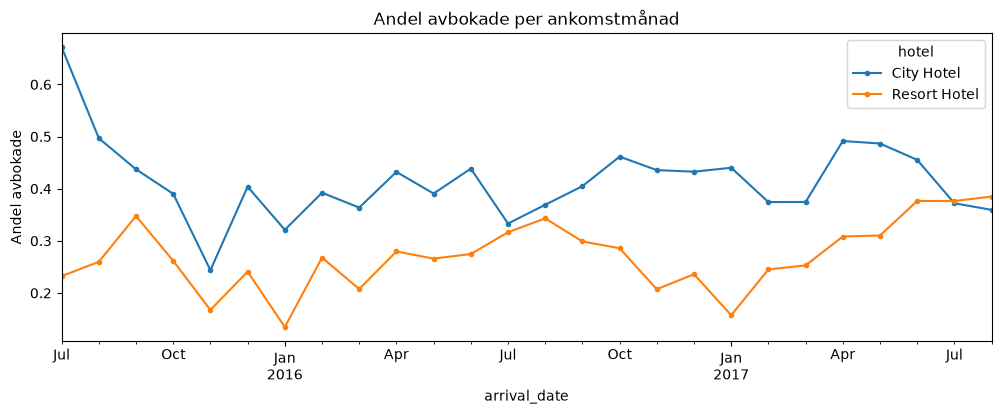

In [6]:
month_order = ["January", "February", "March", "April", "May", "June", "July",
               "August", "September", "October", "November", "December"]
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-"
    + (df["arrival_date_month"].map({m: i + 1 for i, m in enumerate(month_order)})).astype(str) + "-"
    + df["arrival_date_day_of_month"].astype(str))
print("Ankomster:", df["arrival_date"].min().date(), "-", df["arrival_date"].max().date())
 
monthly = (df.set_index("arrival_date")
             .groupby("hotel")["is_canceled"]
             .resample("MS").mean()
             .unstack(level=0))
monthly.plot(figsize=(12, 4), marker=".", title="Andel avbokade per ankomstmånad")
plt.ylabel("Andel avbokade")
plt.show()

## Hur långt i förväg bokade gästen? (lead_time, dagar)

               count   mean    std  min   25%    50%    75%    max
is_canceled                                                       
0            75166.0   80.0   91.0  0.0   9.0   45.0  124.0  737.0
1            44224.0  145.0  119.0  0.0  48.0  113.0  214.0  629.0
             mean   size
lead_grupp              
0-7         0.096  19746
8-30        0.279  18960
31-90       0.377  29553
91-180      0.447  26439
181-365     0.555  21544
365+        0.677   3148


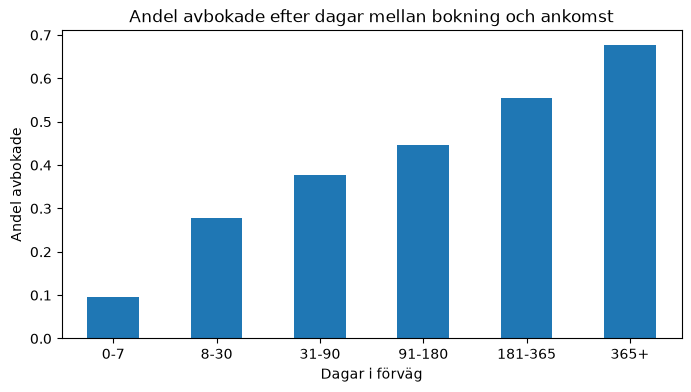

In [7]:
print(df.groupby("is_canceled")["lead_time"].describe().round(0))
 
bins = [-1, 7, 30, 90, 180, 365, 1000]
labels = ["0-7", "8-30", "31-90", "91-180", "181-365", "365+"]
df["lead_grupp"] = pd.cut(df["lead_time"], bins=bins, labels=labels)
lead = df.groupby("lead_grupp", observed=True)["is_canceled"].agg(["mean", "size"])
print(lead.round(3))
 
lead["mean"].plot(kind="bar", figsize=(8, 4), title="Andel avbokade efter dagar mellan bokning och ankomst")
plt.ylabel("Andel avbokade")
plt.xlabel("Dagar i förväg")
plt.xticks(rotation=0)
plt.show()

## Kategoriska variabler: andel avbokade per grupp

In [8]:
for col in ["deposit_type", "market_segment", "customer_type", "distribution_channel", "meal"]:
    print(df.groupby(col)["is_canceled"].agg(["mean", "size"])
            .sort_values("size", ascending=False).round(3), "\n")

               mean    size
deposit_type               
No Deposit    0.284  104641
Non Refund    0.994   14587
Refundable    0.222     162 

                 mean   size
market_segment              
Online TA       0.367  56477
Offline TA/TO   0.343  24219
Groups          0.611  19811
Direct          0.153  12606
Corporate       0.187   5295
Complementary   0.131    743
Aviation        0.219    237
Undefined       1.000      2 

                  mean   size
customer_type                
Transient        0.407  89613
Transient-Party  0.254  25124
Contract         0.310   4076
Group            0.102    577 

                       mean   size
distribution_channel              
TA/TO                 0.410  97870
Direct                0.175  14645
Corporate             0.221   6677
GDS                   0.192    193
Undefined             0.800      5 

            mean   size
meal                   
BB         0.374  92310
HB         0.345  14463
SC         0.372  10650
Undefined  0.245 

**Att granska:** Bokningar med `deposit_type = Non Refund` (ej återbetalningsbara) borde sällan avbokas.  
Om andelen avbokade ändå är mycket hög är det en märklighet i datan som behöver diskuteras.

## Gästens historik

In [9]:
print("Återkommande gäst:")
print(df.groupby("is_repeated_guest")["is_canceled"].agg(["mean", "size"]).round(3))
 
df["tidigare_avbokning"] = (df["previous_cancellations"] > 0).astype(int)
print("\nHar avbokat tidigare:")
print(df.groupby("tidigare_avbokning")["is_canceled"].agg(["mean", "size"]).round(3))
 
print("\nAntal specialönskemål:")
print(df.groupby("total_of_special_requests")["is_canceled"].agg(["mean", "size"]).round(3))

Återkommande gäst:
                    mean    size
is_repeated_guest               
0                  0.378  115580
1                  0.145    3810

Har avbokat tidigare:
                     mean    size
tidigare_avbokning               
0                   0.339  112906
1                   0.916    6484

Antal specialönskemål:
                            mean   size
total_of_special_requests              
0                          0.477  70318
1                          0.220  33226
2                          0.221  12969
3                          0.179   2497
4                          0.106    340
5                          0.050     40


## Land

In [10]:
top_countries = df["country"].value_counts().head(10).index
print(df[df["country"].isin(top_countries)]
        .groupby("country")["is_canceled"].agg(["mean", "size"])
        .sort_values("size", ascending=False).round(3))

          mean   size
country              
PRT      0.566  48590
GBR      0.202  12129
FRA      0.186  10415
ESP      0.254   8568
DEU      0.167   7287
ITA      0.354   3766
IRL      0.247   3375
BEL      0.202   2342
BRA      0.373   2224
NLD      0.184   2104


## Numeriska variabler: korrelation med avbokning

Läckagevariablerna är uteslutna.

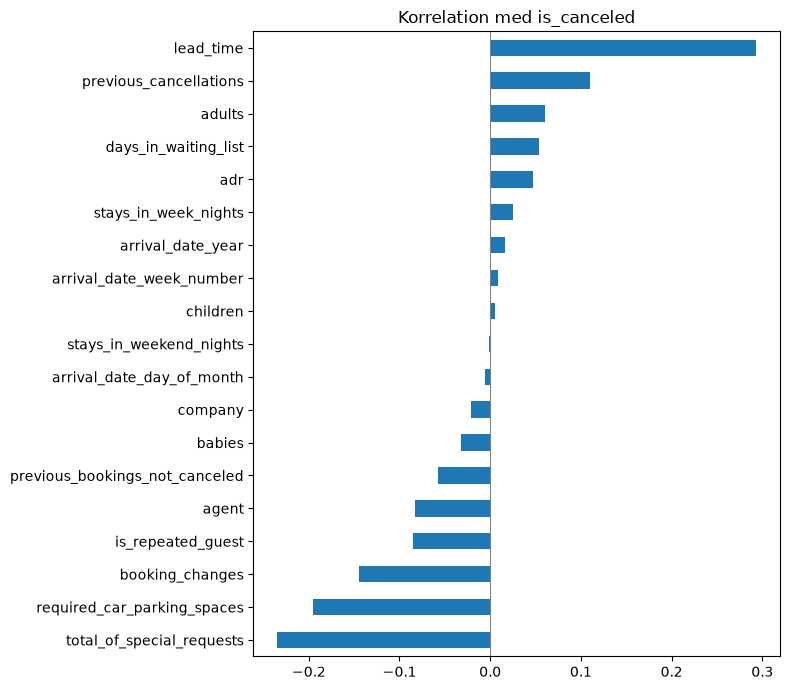

In [11]:
num = (df.drop(columns=LEAKAGE, errors="ignore")
         .select_dtypes("number")
         .drop(columns=["tidigare_avbokning"], errors="ignore"))
corr = num.corr()["is_canceled"].drop("is_canceled").sort_values()
corr.plot(kind="barh", figsize=(8, 7), title="Korrelation med is_canceled")
plt.axvline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()

## Enkla regelbaserade baselines

In [12]:
y = df["is_canceled"]
rules = {
    "Alltid 'avbokas inte'": pd.Series(0, index=df.index),
    "Bokat mer än 90 dagar i förväg": (df["lead_time"] > 90).astype(int),
    "Ej återbetalningsbar (Non Refund)": (df["deposit_type"] == "Non Refund").astype(int),
    "Inga specialönskemål": (df["total_of_special_requests"] == 0).astype(int),
}
rows = []
for name, pred in rules.items():
    tp = ((pred == 1) & (y == 1)).sum()
    rows.append({
        "regel": name,
        "accuracy": (pred == y).mean(),
        "precision": tp / pred.sum() if pred.sum() else np.nan,
        "recall": tp / y.sum(),
        "andel flaggade": pred.mean(),
    })
print(pd.DataFrame(rows).round(3))

                               regel  accuracy  precision  recall  \
0              Alltid 'avbokas inte'     0.630        NaN   0.000   
1     Bokat mer än 90 dagar i förväg     0.635      0.507   0.586   
2  Ej återbetalningsbar (Non Refund)     0.750      0.994   0.328   
3               Inga specialönskemål     0.603      0.477   0.759   

   andel flaggade  
0           0.000  
1           0.428  
2           0.122  
3           0.589  


## Sammanfattning

- **Datan:** 119 390 riktiga bokningar från två hotell i Portugal, ankomster juli 2015 – augusti 2017. Licens CC BY 4.0.
- **Målvariabel:** 37 % avbokade (stadshotellet 41,7 %, semesterhotellet 27,8 %). Baseline "avbokas aldrig" ger 63 % rätt.
- **Starkaste signaler:** tid mellan bokning och ankomst (10 % vid 0–7 dagar, 68 % vid över ett år), tidigare avbokningar (92 % mot 34 %), specialönskemål (48 % utan, ca 20 % med), återkommande gäst och gruppbokning.
- **Läckage som tas bort:** `reservation_status`, `reservation_status_date`, `assigned_room_type`.
- **Att undersöka:** Ej återbetalningsbara bokningar avbokas i 99,4 % av fallen, och portugisiska gäster i 57 %. Möjligen egenheter i registreringen eller dolt läckage.
- **Datakvalitet:** 31 994 identiska rader (27 %) utan boknings-ID att skilja dem åt. 180 bokningar utan gäster, ett negativt pris och ett extremvärde (5 400). `company` och `agent` saknas där inget företag eller ingen agent finns.
- **Uppdelning:** Datan har ankomstdatum, så träning och test kan delas upp i tid (t.ex. test på 2017).